In [ ]:
from cmath import nan
from json.decoder import NaN

import pandas as pd

df = pd.read_csv("Consp2VecD-Final_Dataset/conspiracy.csv", index_col=0)

df = df.reset_index().rename(columns={"index": "type"})

cols = df.columns[df.apply(lambda col: col.astype(str).str.contains("Commento su:").any())]

df[cols] = df[cols].apply(
    lambda col: col.astype(str).str.replace("Commento su:", "", regex=False)
)

import numpy as np

# 0️⃣ se type è index → portalo a colonna (safe)
if "type" not in df.columns:
    df = df.reset_index(names="type")
else:
    df = df.reset_index(drop=True)

# 1️⃣ assicuriamoci che l'id del post si chiami ID_Post
df = df.rename(columns={"post_id": "ID_Post"})

# 2️⃣ contatore commenti che riparte per ogni ID_Post
df["comment_counter"] = (
    df[df["type"] == "comment"]
    .groupby("ID_Post")
    .cumcount() + 1
)

# 3️⃣ costruzione ID finale
df["id"] = df["ID_Post"].astype(str)

mask_comment = df["type"] == "comment"
df.loc[mask_comment, "id"] = (
    df.loc[mask_comment, "ID_Post"].astype(str)
    + "_"
    + df.loc[mask_comment, "comment_counter"].astype(int).astype(str)
)

# 4️⃣ pulizia
df = df.drop(columns=["comment_counter"])

df = df.drop(columns=["ID_Post", "flair", "score", "category"])

df.loc[df["type"] == "comment", "title"] = None

mask_short = (
    (df["type"] == "comment")
    & (df["body"].fillna("").astype(str).str.split().str.len() < 5)
)

df = df[~mask_short].copy()


df.to_csv("Consp2VecD-Final_Dataset/conspiracy_cleaned.csv", index=False, encoding="utf-8")


In [ ]:
import pandas as pd
df = pd.read_csv("Consp2VecD-Final_Dataset/non_conspiracy.csv", index_col=0)

df = df.reset_index().rename(columns={"index": "type"})

cols = df.columns[df.apply(lambda col: col.astype(str).str.contains("Commento su:").any())]

df[cols] = df[cols].apply(
    lambda col: col.astype(str).str.replace("Commento su:", "", regex=False)
)

# 0️⃣ se type è index → portalo a colonna (safe)
if "type" not in df.columns:
    df = df.reset_index(names="type")
else:
    df = df.reset_index(drop=True)

# 1️⃣ assicuriamoci che l'id del post si chiami ID_Post
df = df.rename(columns={"post_id": "ID_Post"})

# 2️⃣ contatore commenti che riparte per ogni ID_Post
df["comment_counter"] = (
    df[df["type"] == "comment"]
    .groupby("ID_Post")
    .cumcount() + 1
)

# 3️⃣ costruzione ID finale
df["id"] = df["ID_Post"].astype(str)

mask_comment = df["type"] == "comment"
df.loc[mask_comment, "id"] = (
    df.loc[mask_comment, "ID_Post"].astype(str)
    + "_"
    + df.loc[mask_comment, "comment_counter"].astype(int).astype(str)
)

# 4️⃣ pulizia
df = df.drop(columns=["comment_counter"])

df = df.drop(columns=["ID_Post", "flair", "score", "category"])

df.loc[df["type"] == "comment", "title"] = None

mask_short = (
    (df["type"] == "comment")
    & (df["body"].fillna("").astype(str).str.split().str.len() < 5)
)

df = df[~mask_short].copy()

df.to_csv("Consp2VecD-Final_Dataset/non_conspiracy_cleaned.csv", index=False, encoding="utf-8")


In [ ]:

# df: DataFrame con colonne ['type','title','author','body','created_utc','subreddit_name','id']
def cut_date(df):
    d = df.copy()

    # 1) Parse date (created_utc può essere epoch seconds oppure datetime string)
    if np.issubdtype(d["created_utc"].dtype, np.number):
        d["created_dt"] = pd.to_datetime(d["created_utc"], unit="s", utc=True, errors="coerce")
    else:
        d["created_dt"] = pd.to_datetime(d["created_utc"], utc=True, errors="coerce")

    cutoff = pd.Timestamp("2025-01-01", tz="UTC")

    # 2) Definisci l'id "base" del post: per i commenti togli il suffisso _x
    #    (es. abc123_4 -> abc123)
    d["base_id"] = d["id"].astype(str).str.split("_", n=1).str[0]

    # 3) Trova i post antecedenti a gennaio 2025 (da eliminare)
    old_posts_base_ids = d.loc[
        (d["type"].astype(str).str.lower() == "post") & (d["created_dt"] < cutoff),
        "base_id"
    ].unique()

    # 4) Elimina:
    #    - i post vecchi
    #    - TUTTI i commenti associati (stesso base_id)
    mask_drop = d["base_id"].isin(old_posts_base_ids)

    filtered_df = d.loc[~mask_drop].drop(columns=["created_dt", "base_id"]).reset_index(drop=True)

    return filtered_df


In [ ]:
conspiracy = pd.read_csv("Consp2VecD-Final_Dataset/conspiracy_cleaned.csv", index_col=0)
non_conspiracy = pd.read_csv("Consp2VecD-Final_Dataset/non_conspiracy_cleaned.csv", index_col=0)

conspiracy.reset_index(drop=True, inplace=True)
non_conspiracy.reset_index(drop=True, inplace=True)

In [ ]:
conspiracy

In [ ]:
conspiracy = cut_date(conspiracy)
non_conspiracy = cut_date(non_conspiracy)


conspiracy["n_type"] = conspiracy.index
conspiracy = conspiracy.reset_index(drop=True)
conspiracy["type"] = conspiracy["n_type"]
conspiracy.drop(columns=["n_type"], inplace=True)

non_conspiracy["n_type"] = non_conspiracy.index
non_conspiracy = non_conspiracy.reset_index(drop=True)
non_conspiracy["type"] = non_conspiracy["n_type"]
non_conspiracy.drop(columns=["n_type"], inplace=True)

conspiracy.to_csv("Consp2VecD-Final_Dataset/conspiracy_cleaned.csv", index=False, encoding="utf-8")
non_conspiracy.to_csv("Consp2VecD-Final_Dataset/non_conspiracy_cleaned.csv", index=False, encoding="utf-8")


In [79]:
import pandas
conspiracy = pd.read_csv("consp2vec_dataset/conspiracy.csv")
non_conspiracy = pd.read_csv("consp2vec_dataset/non_conspiracy.csv")
emotions_conspiracy = pd.read_csv("consp2vec_dataset/emotions_conspiracy.csv")
emotions_non_conspiracy = pd.read_csv("consp2vec_dataset/emotions_non_conspiracy.csv")

/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_14411/1507527331.py:3: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  non_conspiracy = pd.read_csv("consp2vec_dataset/non_conspiracy.csv")


/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_14411/3520540856.py:70: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d.groupby([pd.Grouper(freq=freq), "subreddit_grp"])
/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_14411/3520540856.py:70: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  d.groupby([pd.Grouper(freq=freq), "subreddit_grp"])


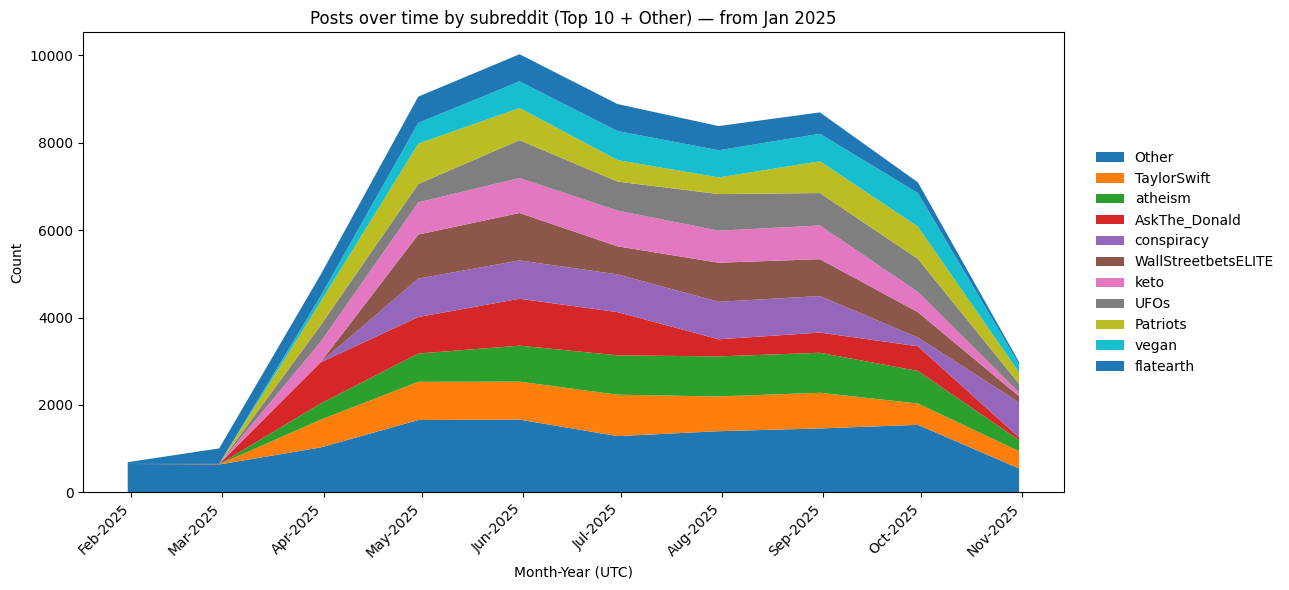

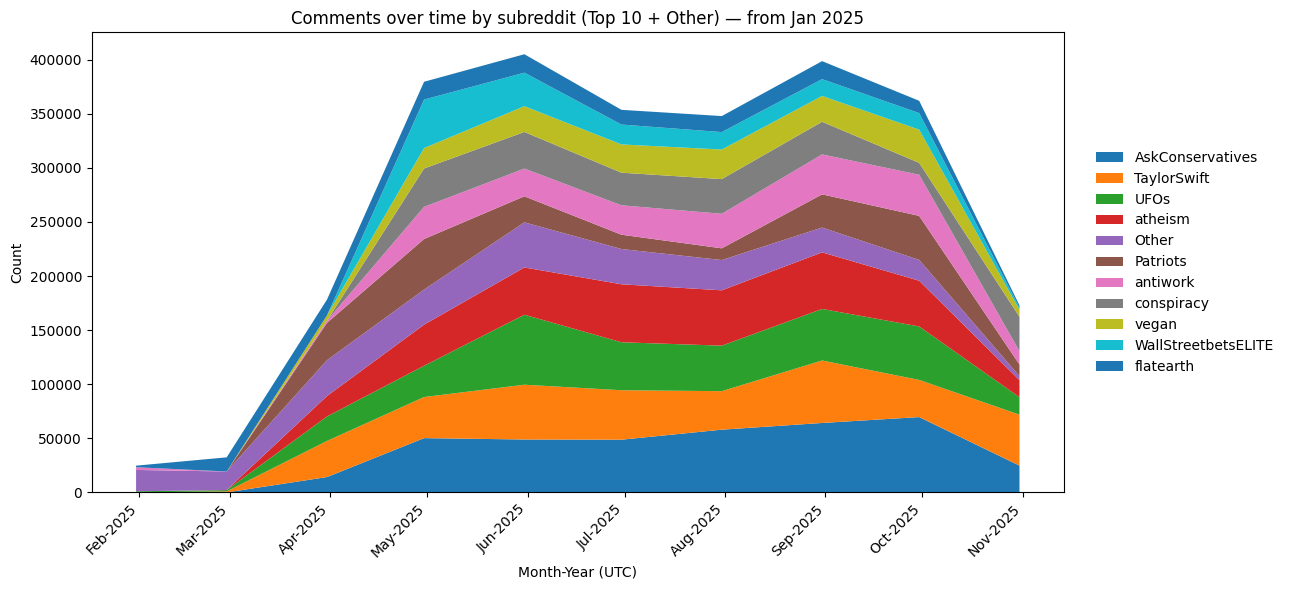

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import locale

START_DATE = pd.Timestamp("2025-01-01", tz="UTC")  # da gennaio 2025
FREQ = "M"      # "M" mese, "W" settimana, "D" giorno
TOP_N = 10      # numero subreddit principali da mostrare

# ---------------------------
# Robust datetime parsing
# ---------------------------
def add_created_dt(df: pd.DataFrame, col="created_utc") -> pd.DataFrame:
    out = df.copy()

    s = pd.to_numeric(out[col], errors="coerce")
    dt_s = pd.to_datetime(s, unit="s", utc=True, errors="coerce")

    if dt_s.notna().mean() < 0.5:
        dt_ms = pd.to_datetime(s, unit="ms", utc=True, errors="coerce")
        out["created_dt"] = dt_ms if dt_ms.notna().mean() > dt_s.notna().mean() else dt_s
    else:
        out["created_dt"] = dt_s

    if out["created_dt"].notna().mean() < 0.5:
        dt_str = pd.to_datetime(out[col], utc=True, errors="coerce")
        if dt_str.notna().mean() > out["created_dt"].notna().mean():
            out["created_dt"] = dt_str

    out = out.dropna(subset=["created_dt"]).sort_values("created_dt").set_index("created_dt")
    return out

# ---------------------------
# Split posts/comments
# ---------------------------
def split_posts_comments(conspiracy: pd.DataFrame):
    if getattr(conspiracy.index, "name", None) == "type":
        conspiracy = conspiracy.reset_index()

    req = {"type", "subreddit_name", "created_utc"}
    missing = req - set(conspiracy.columns)
    if missing:
        raise ValueError(f"Colonne mancanti: {missing}")

    df = conspiracy.copy()
    df["type_norm"] = df["type"].astype(str).str.lower().str.strip()

    posts_df = df[df["type_norm"].isin(["post", "submission"])].copy()
    comments_df = df[df["type_norm"].isin(["comment"])].copy()
    return posts_df, comments_df

# ---------------------------
# Build time x subreddit matrix (top N + Other), filtered from START_DATE
# ---------------------------
def time_by_subreddit(df: pd.DataFrame, start_date=START_DATE, freq="M", top_n=10) -> pd.DataFrame:
    d = add_created_dt(df, col="created_utc")

    # filtro temporale
    d = d.loc[d.index >= start_date].copy()

    d["subreddit_name"] = d["subreddit_name"].astype(str).str.strip()

    if d.empty:
        return pd.DataFrame()

    top = d["subreddit_name"].value_counts().head(top_n).index
    d["subreddit_grp"] = d["subreddit_name"].where(d["subreddit_name"].isin(top), other="Other")

    g = (
        d.groupby([pd.Grouper(freq=freq), "subreddit_grp"])
         .size()
         .unstack(fill_value=0)
         .sort_index()
    )

    # ordina colonne per totale desc
    g = g[g.sum().sort_values(ascending=False).index]
    return g

# ---------------------------
# Plot stacked area
# ---------------------------
def plot_stacked_area(g: pd.DataFrame, title: str):
    try:
        locale.setlocale(locale.LC_TIME, "en_US.UTF-8")
    except locale.Error:
        pass

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.stackplot(g.index, [g[c].values for c in g.columns], labels=list(g.columns))
    ax.set_title(title)
    ax.set_xlabel("Month-Year (UTC)")
    ax.set_ylabel("Count")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
    fig.autofmt_xdate(rotation=45)

    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

# ===========================
# RUN
# ===========================
posts_df, comments_df = split_posts_comments(conspiracy)

posts_g = time_by_subreddit(posts_df, start_date=START_DATE, freq=FREQ, top_n=TOP_N)
comments_g = time_by_subreddit(comments_df, start_date=START_DATE, freq=FREQ, top_n=TOP_N)

if posts_g.empty:
    raise ValueError("Nessun POST dal 2025-01-01 (o parsing created_utc fallito / type non corrisponde).")
if comments_g.empty:
    raise ValueError("Nessun COMMENTO dal 2025-01-01 (o parsing created_utc fallito / type non corrisponde).")

plot_stacked_area(posts_g, f"Posts over time by subreddit (Top {TOP_N} + Other) — from Jan 2025")
plot_stacked_area(comments_g, f"Comments over time by subreddit (Top {TOP_N} + Other) — from Jan 2025")


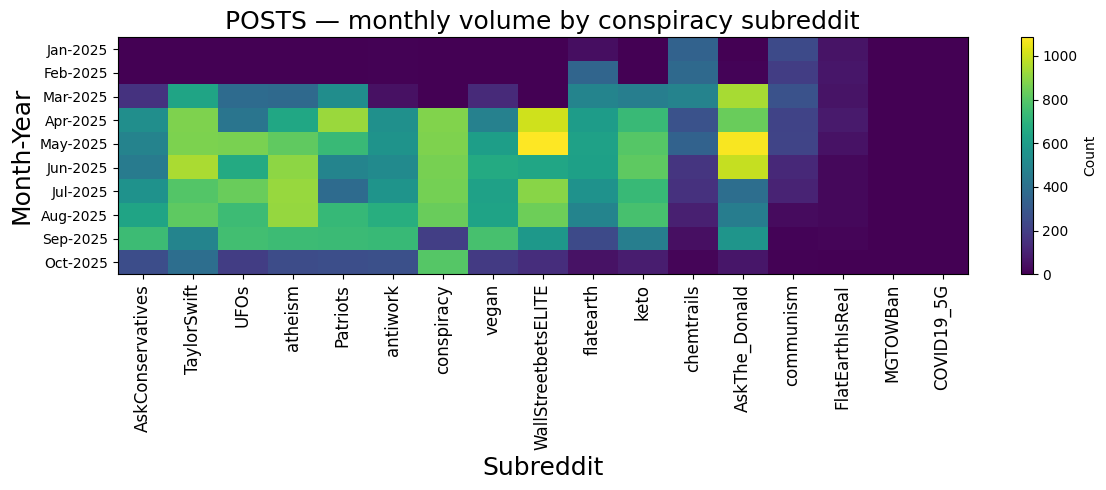

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import locale

START_DATE = pd.Timestamp("2025-01-01", tz="UTC")
FREQ = "MS"  # Month Start: più comodo per avere mesi "puliti" (2025-01-01, 2025-02-01, ...)

# ---------------------------
# Robust datetime parsing
# ---------------------------
def add_created_dt(df: pd.DataFrame, col="created_utc") -> pd.DataFrame:
    out = df.copy()
    s = pd.to_numeric(out[col], errors="coerce")

    dt_s = pd.to_datetime(s, unit="s", utc=True, errors="coerce")
    if dt_s.notna().mean() < 0.5:
        dt_ms = pd.to_datetime(s, unit="ms", utc=True, errors="coerce")
        out["created_dt"] = dt_ms if dt_ms.notna().mean() > dt_s.notna().mean() else dt_s
    else:
        out["created_dt"] = dt_s

    if out["created_dt"].notna().mean() < 0.5:
        dt_str = pd.to_datetime(out[col], utc=True, errors="coerce")
        if dt_str.notna().mean() > out["created_dt"].notna().mean():
            out["created_dt"] = dt_str

    out = out.dropna(subset=["created_dt"]).sort_values("created_dt").set_index("created_dt")
    return out

def split_posts_comments(conspiracy: pd.DataFrame):
    if getattr(conspiracy.index, "name", None) == "type":
        conspiracy = conspiracy.reset_index()

    req = {"type", "subreddit_name", "created_utc"}
    missing = req - set(conspiracy.columns)
    if missing:
        raise ValueError(f"Colonne mancanti: {missing}")

    df = conspiracy.copy()
    df["type_norm"] = df["type"].astype(str).str.lower().str.strip()

    posts_df = df[df["type_norm"].isin(["post", "submission"])].copy()
    comments_df = df[df["type_norm"].isin(["comment"])].copy()

    # se qui uno dei due è 0, probabilmente type ha valori diversi
    # print(df["type_norm"].value_counts().head(20))

    return posts_df, comments_df

def make_month_subreddit_matrix(df: pd.DataFrame, start_date=START_DATE, freq=FREQ) -> pd.DataFrame:
    d = add_created_dt(df, col="created_utc")
    d = d.loc[d.index >= start_date].copy()

    d["subreddit_name"] = d["subreddit_name"].astype(str).str.strip()
    if d.empty:
        return pd.DataFrame()

    mat = (
        d.groupby([pd.Grouper(freq=freq), "subreddit_name"])
         .size()
         .unstack(fill_value=0)
         .sort_index()
    )
    return mat

def align_matrices(posts_mat: pd.DataFrame, comments_mat: pd.DataFrame, start_date=START_DATE):
    # 1) Unione di tutti i subreddit
    all_subs = posts_mat.columns.union(comments_mat.columns)

    # 2) Ordine unico: per volume complessivo (post+commenti)
    totals = posts_mat.reindex(columns=all_subs, fill_value=0).sum(axis=0) + \
             comments_mat.reindex(columns=all_subs, fill_value=0).sum(axis=0)
    subs_order = totals.sort_values(ascending=False).index

    # 3) Intervallo mesi completo (così non “mancano gruppi”/righe)
    max_idx = None
    if not posts_mat.empty:
        max_idx = posts_mat.index.max() if max_idx is None else max(max_idx, posts_mat.index.max())
    if not comments_mat.empty:
        max_idx = comments_mat.index.max() if max_idx is None else max(max_idx, comments_mat.index.max())

    if max_idx is None:
        raise ValueError("Entrambe le matrici sono vuote dopo il filtro temporale.")

    full_months = pd.date_range(start=start_date.floor("D"), end=max_idx, freq=FREQ, tz="UTC")

    # 4) Reindex: stesso asse temporale + stesse colonne, riempi 0
    posts_aligned = posts_mat.reindex(index=full_months, columns=subs_order, fill_value=0)
    comments_aligned = comments_mat.reindex(index=full_months, columns=subs_order, fill_value=0)

    return posts_aligned, comments_aligned

def plot_heatmap(mat: pd.DataFrame, title: str, max_xticks: int = 30):
    # mesi in inglese
    try:
        locale.setlocale(locale.LC_TIME, "en_US.UTF-8")
    except locale.Error:
        pass

    n_rows, n_cols = mat.shape
    fig_w = max(12, min(0.25 * n_cols, 60))
    fig_h = max(5, min(0.35 * n_rows, 25))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(mat.values, aspect="auto")

    ax.set_title(title, size=18)
    ax.set_xlabel("Subreddit", size=18)
    ax.set_ylabel("Month-Year", size=18)

    y_labels = [idx.strftime("%b-%Y") for idx in mat.index.to_pydatetime()]
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)

    # tick X: tutti se pochi, altrimenti diradati
    if n_cols <= max_xticks:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(mat.columns, rotation=90, size=12)
    else:
        step = max(1, n_cols // max_xticks)
        xt = list(range(0, n_cols, step))
        ax.set_xticks(xt)
        ax.set_xticklabels([mat.columns[i] for i in xt], rotation=90, size=12)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Count")

    plt.tight_layout()
    plt.savefig("conspiracy_heatmap.pdf", dpi=300)
    plt.show()

# ===========================
# RUN
# ===========================
posts_df, comments_df = split_posts_comments(conspiracy)

posts_mat = make_month_subreddit_matrix(posts_df)
comments_mat = make_month_subreddit_matrix(comments_df)

# Allineamento: stesso ordine subreddit + mesi completi
posts_mat, comments_mat = align_matrices(posts_mat, comments_mat, start_date=START_DATE)

plot_heatmap(posts_mat, "POSTS — monthly volume by conspiracy subreddit")
#plot_heatmap(comments_mat, "COMMENTS — monthly volume by subreddit (aligned) — from Jan 2025")


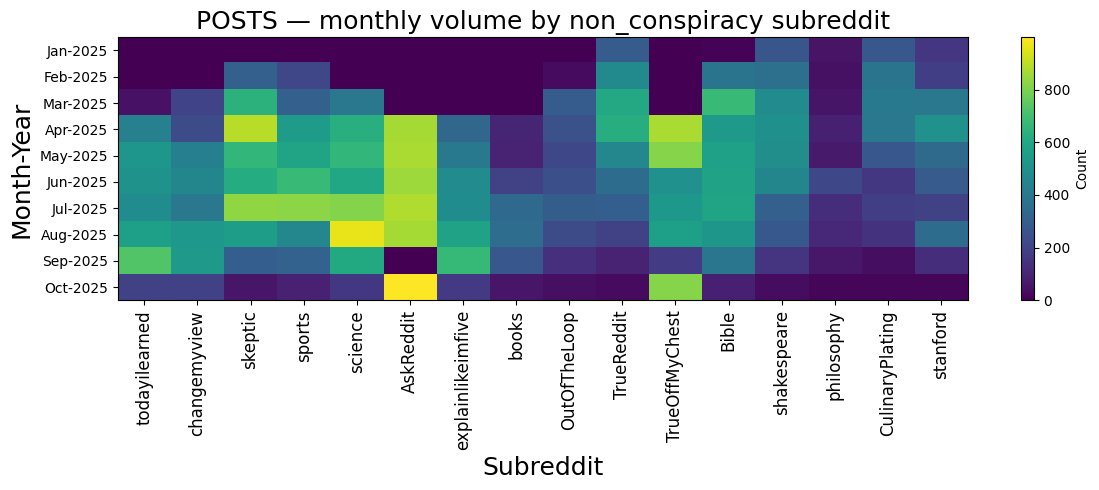

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import locale

START_DATE = pd.Timestamp("2025-01-01", tz="UTC")
FREQ = "MS"  # Month Start: più comodo per avere mesi "puliti" (2025-01-01, 2025-02-01, ...)

# ---------------------------
# Robust datetime parsing
# ---------------------------
def add_created_dt(df: pd.DataFrame, col="created_utc") -> pd.DataFrame:
    out = df.copy()
    s = pd.to_numeric(out[col], errors="coerce")

    dt_s = pd.to_datetime(s, unit="s", utc=True, errors="coerce")
    if dt_s.notna().mean() < 0.5:
        dt_ms = pd.to_datetime(s, unit="ms", utc=True, errors="coerce")
        out["created_dt"] = dt_ms if dt_ms.notna().mean() > dt_s.notna().mean() else dt_s
    else:
        out["created_dt"] = dt_s

    if out["created_dt"].notna().mean() < 0.5:
        dt_str = pd.to_datetime(out[col], utc=True, errors="coerce")
        if dt_str.notna().mean() > out["created_dt"].notna().mean():
            out["created_dt"] = dt_str

    out = out.dropna(subset=["created_dt"]).sort_values("created_dt").set_index("created_dt")
    return out

def split_posts_comments(non_conspiracy: pd.DataFrame):
    if getattr(non_conspiracy.index, "name", None) == "type":
        non_conspiracy = non_conspiracy.reset_index()

    req = {"type", "subreddit_name", "created_utc"}
    missing = req - set(conspiracy.columns)
    if missing:
        raise ValueError(f"Colonne mancanti: {missing}")

    df = non_conspiracy.copy()
    df["type_norm"] = df["type"].astype(str).str.lower().str.strip()

    posts_df = df[df["type_norm"].isin(["post", "submission"])].copy()
    comments_df = df[df["type_norm"].isin(["comment"])].copy()

    # se qui uno dei due è 0, probabilmente type ha valori diversi
    # print(df["type_norm"].value_counts().head(20))

    return posts_df, comments_df

def make_month_subreddit_matrix(df: pd.DataFrame, start_date=START_DATE, freq=FREQ) -> pd.DataFrame:
    d = add_created_dt(df, col="created_utc")
    d = d.loc[d.index >= start_date].copy()

    d["subreddit_name"] = d["subreddit_name"].astype(str).str.strip()
    if d.empty:
        return pd.DataFrame()

    mat = (
        d.groupby([pd.Grouper(freq=freq), "subreddit_name"])
         .size()
         .unstack(fill_value=0)
         .sort_index()
    )
    return mat

def align_matrices(posts_mat: pd.DataFrame, comments_mat: pd.DataFrame, start_date=START_DATE):
    # 1) Unione di tutti i subreddit
    all_subs = posts_mat.columns.union(comments_mat.columns)

    # 2) Ordine unico: per volume complessivo (post+commenti)
    totals = posts_mat.reindex(columns=all_subs, fill_value=0).sum(axis=0) + \
             comments_mat.reindex(columns=all_subs, fill_value=0).sum(axis=0)
    subs_order = totals.sort_values(ascending=False).index

    # 3) Intervallo mesi completo (così non “mancano gruppi”/righe)
    max_idx = None
    if not posts_mat.empty:
        max_idx = posts_mat.index.max() if max_idx is None else max(max_idx, posts_mat.index.max())
    if not comments_mat.empty:
        max_idx = comments_mat.index.max() if max_idx is None else max(max_idx, comments_mat.index.max())

    if max_idx is None:
        raise ValueError("Entrambe le matrici sono vuote dopo il filtro temporale.")

    full_months = pd.date_range(start=start_date.floor("D"), end=max_idx, freq=FREQ, tz="UTC")

    # 4) Reindex: stesso asse temporale + stesse colonne, riempi 0
    posts_aligned = posts_mat.reindex(index=full_months, columns=subs_order, fill_value=0)
    comments_aligned = comments_mat.reindex(index=full_months, columns=subs_order, fill_value=0)

    return posts_aligned, comments_aligned

def plot_heatmap(mat: pd.DataFrame, title: str, max_xticks: int = 30):
    # mesi in inglese
    try:
        locale.setlocale(locale.LC_TIME, "en_US.UTF-8")
    except locale.Error:
        pass

    n_rows, n_cols = mat.shape
    fig_w = max(12, min(0.25 * n_cols, 60))
    fig_h = max(5, min(0.35 * n_rows, 25))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(mat.values, aspect="auto")

    ax.set_title(title, size=18)
    ax.set_xlabel("Subreddit", size=18)
    ax.set_ylabel("Month-Year", size=18)

    y_labels = [idx.strftime("%b-%Y") for idx in mat.index.to_pydatetime()]
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)

    # tick X: tutti se pochi, altrimenti diradati
    if n_cols <= max_xticks:
        ax.set_xticks(range(n_cols))
        ax.set_xticklabels(mat.columns, rotation=90, size=12)
    else:
        step = max(1, n_cols // max_xticks)
        xt = list(range(0, n_cols, step))
        ax.set_xticks(xt)
        ax.set_xticklabels([mat.columns[i] for i in xt], rotation=90, size=12)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Count")

    plt.tight_layout()
    plt.savefig("non_conspiracy_heatmap.pdf", dpi=300)
    plt.show()


# ===========================
# RUN
# ===========================
posts_df, comments_df = split_posts_comments(non_conspiracy)

posts_mat = make_month_subreddit_matrix(posts_df)
comments_mat = make_month_subreddit_matrix(comments_df)

# Allineamento: stesso ordine subreddit + mesi completi
posts_mat, comments_mat = align_matrices(posts_mat, comments_mat, start_date=START_DATE)

plot_heatmap(posts_mat, "POSTS — monthly volume by non_conspiracy subreddit")
#plot_heatmap(comments_mat, "COMMENTS — monthly volume by subreddit (aligned) — from Jan 2025")


In [131]:
non_conspiracy

,type,title,author,body,created_utc,subreddit_name,id
0,post,What’s a personal internet hack you use that m...,Comfortable-Union377,NaN,2025-04-14 12:03:06,AskReddit,1jyx5ca
1,comment,NaN,Adro87,Ctrl+Shift+t \nReopens the last browser tab t...,2025-04-14 12:17:45,AskReddit,1jyx5ca_1
2,comment,NaN,terryjuicelawson,Soulseek is still around and excellent for dow...,2025-04-14 12:56:46,AskReddit,1jyx5ca_2
3,comment,NaN,i_wannabe_adored,* Get a great music recommendation each day an...,2025-04-14 13:30:03,AskReddit,1jyx5ca_3
4,comment,NaN,ddxv,"I started self hosting things: websites, datab...",2025-04-14 12:24:56,AskReddit,1jyx5ca_4
...,...,...,...,...,...,...,...
3594917,comment,NaN,Prufrock451,"You're both wrong, the best version is the 165...",NaN,todayilearned,4n6zzp_7
3594918,comment,NaN,vendettaatreides,Then you don't know jack about sci-fi books be...,NaN,todayilearned,4n6zzp_8
3594919,comment,NaN,NaN,"No, Johnny Rico is from the Philippines, not A...",NaN,todayilearned,4n6zzp_9
3594920,comment,NaN,sg3niner,Apparently YOU are the one who doesn't know ja...,NaN,todayilearned,4n6zzp_10


In [100]:
import numpy as np

def subreddit_stats(df: pd.DataFrame) -> pd.DataFrame:
    required = {'title','author','body','created_utc','subreddit_name','id','type'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Copia per non modificare df originale
    d = df.copy()

    # created_utc: accetta sia timestamp (secondi) sia stringhe datetime
    if np.issubdtype(d["created_utc"].dtype, np.number):
        d["created_dt"] = pd.to_datetime(d["created_utc"], unit="s", utc=True, errors="coerce")
    else:
        d["created_dt"] = pd.to_datetime(d["created_utc"], utc=True, errors="coerce")

    # body words: conta parole in modo robusto (NaN -> 0)
    d["body"] = d["body"].fillna("").astype(str)
    d["body_word_count"] = d["body"].str.findall(r"\b\w+\b").str.len()

    # Normalizza type (minuscole e strip)
    d["type"] = d["type"].astype(str).str.strip().str.lower()

    # Aggregazioni per subreddit
    out = (
        d.groupby("subreddit_name", dropna=False)
         .agg(
            Total_Posts=("type", lambda s: (s == "post").sum()),
            Total_Comments=("type", lambda s: (s == "comment").sum()),
            Oldest_Date=("created_dt", "min"),
            Newest_Date=("created_dt", "max"),
            Avg_Words_per_Body=("body_word_count", "mean"),
         )
         .reset_index()
    )

    # Arrotonda media parole (opzionale)
    out["Avg_Words_per_Body"] = out["Avg_Words_per_Body"].round(2)

    # Se vuoi date senza timezone, decommenta:
    # out["Oldest_Date"] = out["Oldest_Date"].dt.tz_convert(None)
    # out["Newest_Date"] = out["Newest_Date"].dt.tz_convert(None)

    return out


In [83]:
stats = subreddit_stats(conspiracy)
print(stats.sort_values("subreddit_name").to_string(index=False))

     subreddit_name  Total_Posts  Total_Comments               Oldest_Date               Newest_Date  Avg_Words_per_Body
   AskConservatives         4384          418759 2025-03-25 16:21:58+00:00 2025-10-07 16:13:40+00:00               61.20
      AskThe_Donald         6333           37999 2024-11-06 15:43:00+00:00 2025-10-07 11:59:30+00:00               32.08
         COVID19_5G          417             316 2020-03-05 00:43:10+00:00 2025-02-19 23:04:18+00:00               49.99
    FlatEarthIsReal         2931           71224 2021-02-15 17:31:43+00:00 2025-10-07 19:13:51+00:00               54.48
           MGTOWBan         1636           22472 2021-03-26 01:11:08+00:00 2025-04-16 07:20:23+00:00               48.67
           Patriots         5578          257617 2025-03-10 16:15:03+00:00 2025-10-07 20:37:29+00:00               33.20
        TaylorSwift         6478          382852 2025-02-05 09:45:34+00:00 2025-10-07 21:51:08+00:00               31.56
               UFOs         5538

In [ ]:
stats = subreddit_stats(non_conspiracy)
print(stats.sort_values("subreddit_name").to_string(index=False))

In [ ]:
conspiracy

In [88]:
total_post = 0
total_comment = 0
words = 0

for g in conspiracy["subreddit_name"].unique():

    subset = conspiracy[conspiracy["subreddit_name"] == g].copy()
    subset = subset.fillna("")

    num_post = (subset["type"] == "post").sum()
    num_comment = (subset["type"] == "comment").sum()

    total_post += num_post
    total_comment += num_comment

    word_count = (
        subset["title"].str.split().str.len().sum() +
        subset["body"].str.split().str.len().sum()
    )

    words += word_count


    print(f"Subreddit: {g}")
    print(f"Posts: {num_post}, Comments: {num_comment}, Words: {word_count/len(subset)}")
    print("-" * 40)

print("TOTAL POSTS:", total_post)
print("TOTAL COMMENTS:", total_comment)
print("TOTAL WORDS:", words)


Subreddit: AskConservatives
Posts: 4384, Comments: 418759, Words: 57.68910273831778
----------------------------------------
Subreddit: AskThe_Donald
Posts: 6333, Comments: 37999, Words: 31.87805648290174
----------------------------------------
Subreddit: COVID19_5G
Posts: 417, Comments: 316, Words: 51.903137789904505
----------------------------------------
Subreddit: FlatEarthIsReal
Posts: 2931, Comments: 71224, Words: 52.41509001415953
----------------------------------------
Subreddit: MGTOWBan
Posts: 1636, Comments: 22472, Words: 46.83959681433549
----------------------------------------
Subreddit: Patriots
Posts: 5578, Comments: 257617, Words: 31.984255020042173
----------------------------------------
Subreddit: TaylorSwift
Posts: 6478, Comments: 382852, Words: 30.391934862456015
----------------------------------------
Subreddit: UFOs
Posts: 5538, Comments: 364374, Words: 49.675222755682434
----------------------------------------
Subreddit: WallStreetbetsELITE
Posts: 6041, Co

In [89]:
total_post = 0
total_comment = 0
words = 0

for g in non_conspiracy["subreddit_name"].unique():

    subset = non_conspiracy[non_conspiracy["subreddit_name"] == g].copy()
    subset = subset.fillna("")

    num_post = (subset["type"] == "post").sum()
    num_comment = (subset["type"] == "comment").sum()

    total_post += num_post
    total_comment += num_comment

    word_count = (
        subset["title"].str.split().str.len().sum() +
        subset["body"].str.split().str.len().sum()
    )

    words += word_count

    print(f"Subreddit: {g}")
    print(f"Posts: {num_post}, Comments: {num_comment}, Words: {word_count/len(subset)}")
    print("-" * 40)

print("TOTAL POSTS:", total_post)
print("TOTAL COMMENTS:", total_comment)
print("TOTAL WORDS:", words)


Subreddit: AskReddit
Posts: 6181, Comments: 280269, Words: 32.11659975562925
----------------------------------------
Subreddit: Bible
Posts: 5210, Comments: 107732, Words: 88.45163889429973
----------------------------------------
Subreddit: CulinaryPlating
Posts: 5247, Comments: 59706, Words: 32.463057903407076
----------------------------------------
Subreddit: OutOfTheLoop
Posts: 1963, Comments: 159383, Words: 49.9866869956491
----------------------------------------
Subreddit: TrueOffMyChest
Posts: 5161, Comments: 107158, Words: 70.5833830429402
----------------------------------------
Subreddit: TrueReddit
Posts: 5165, Comments: 190570, Words: 54.70171405216236
----------------------------------------
Subreddit: books
Posts: 1541, Comments: 160830, Words: 48.48551157534289
----------------------------------------
Subreddit: changemyview
Posts: 3387, Comments: 517444, Words: 76.50376033684631
----------------------------------------
Subreddit: explainlikeimfive
Posts: 3492, Commen

Emotion Analysis

In [ ]:
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import pandas as pd

# Carica il modello di SpaCy
nlp = spacy.load('en_core_web_sm')
nlp.add_pipe('spacytextblob')

def get_sentiment(row):
    # Gestisci i valori NaN nei titoli e nei corpi
    title = row["title"] if pd.notna(row["title"]) else ""
    body = row["body"] if pd.notna(row["body"]) else ""

    # Combina il titolo e il corpo
    text = title + " " + body

    # Analizza il testo con SpaCy
    doc = nlp(text)

    # Estrai polarità e soggettività
    return doc._.blob.polarity, doc._.blob.subjectivity


In [ ]:
from tqdm import tqdm

print(len(conspiracy))
conspiracy_sentiment = 0
conspiracy_polarity = 0
for row in tqdm(conspiracy.iterrows()):
    s,p = get_sentiment(row[1])
    conspiracy_sentiment + s
    conspiracy_polarity + p


print(conspiracy_sentiment/len(conspiracy))



In [132]:
emotions_conspiracy.columns

Index(['id', 'neutral', 'confusion', 'curiosity', 'approval', 'love',
       'realization', 'disapproval', 'surprise', 'disappointment', 'annoyance',
       'optimism', 'sadness', 'caring', 'fear', 'anger', 'excitement',
       'desire', 'admiration', 'nervousness', 'joy', 'disgust',
       'embarrassment', 'remorse', 'amusement', 'grief', 'relief', 'gratitude',
       'pride'],
      dtype='object')

In [111]:
emotions_conspiracy.columns

Index(['id', 'neutral', 'confusion', 'curiosity', 'approval', 'love',
       'realization', 'disapproval', 'surprise', 'disappointment', 'annoyance',
       'optimism', 'sadness', 'caring', 'fear', 'anger', 'excitement',
       'desire', 'admiration', 'nervousness', 'joy', 'disgust',
       'embarrassment', 'remorse', 'amusement', 'grief', 'relief', 'gratitude',
       'pride'],
      dtype='object')

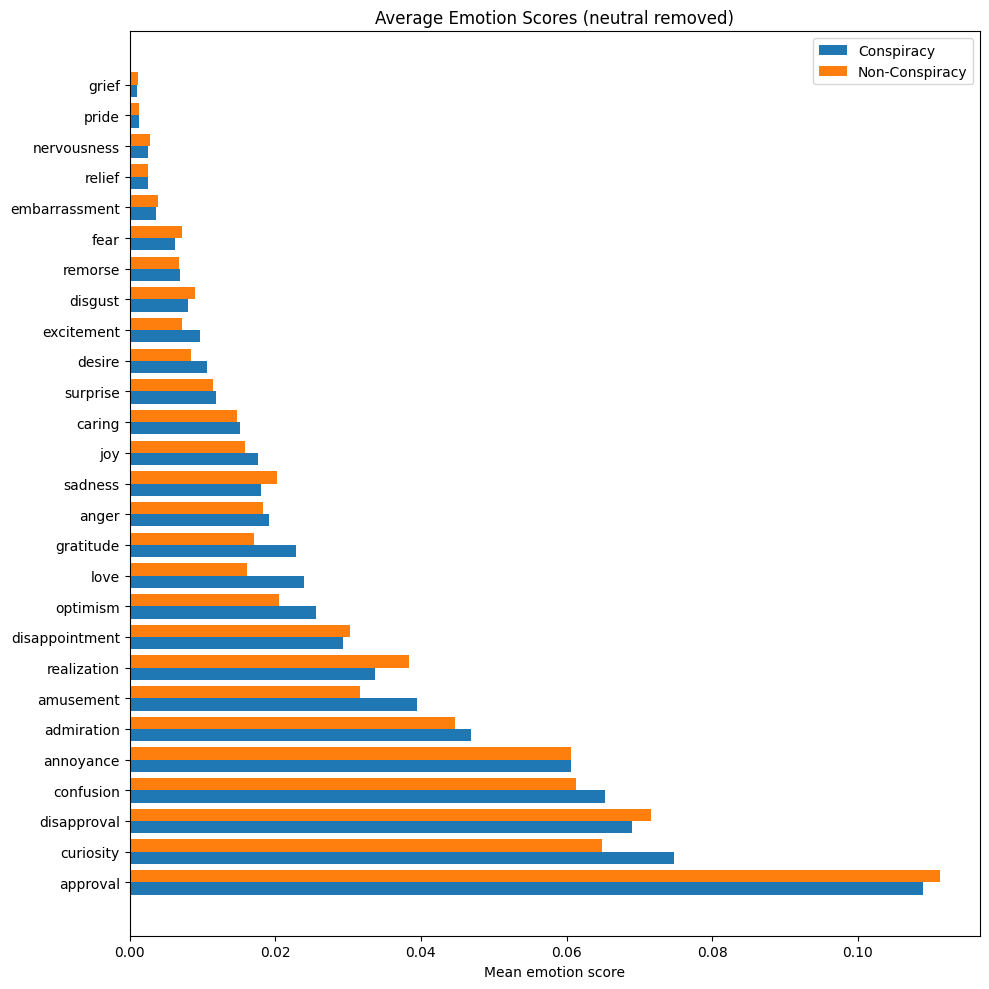

Saved: emotion_means_side_by_side_no_neutral.csv


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Copia dataframe
df_c = emotions_conspiracy.copy()
df_n = emotions_non_conspiracy.copy()

# Seleziona colonne comuni (escludo id e neutral)
cols_c = {c for c in df_c.columns if c not in ["id", "neutral"]}
cols_n = {c for c in df_n.columns if c not in ["id", "neutral"]}
emotion_cols = sorted(list(cols_c.intersection(cols_n)))

# Conversione a numerico
df_c[emotion_cols] = df_c[emotion_cols].apply(pd.to_numeric, errors="coerce")
df_n[emotion_cols] = df_n[emotion_cols].apply(pd.to_numeric, errors="coerce")

# Calcolo medie
mean_c = df_c[emotion_cols].mean()
mean_n = df_n[emotion_cols].mean()

# DataFrame comparativo
comp = pd.DataFrame({
    "Conspiracy": mean_c,
    "Non-Conspiracy": mean_n
})

# Ordina per media Conspiracy (puoi cambiare criterio)
comp = comp.sort_values("Conspiracy", ascending=False)

# Plot
y = np.arange(len(comp))
height = 0.4

fig, ax = plt.subplots(figsize=(10, 10))

ax.barh(y - height/2, comp["Conspiracy"], height=height, label="Conspiracy")
ax.barh(y + height/2, comp["Non-Conspiracy"], height=height, label="Non-Conspiracy")

ax.set_yticks(y)
ax.set_yticklabels(comp.index)
ax.set_xlabel("Mean emotion score")
ax.set_title("Average Emotion Scores (neutral removed)")
ax.legend()

plt.tight_layout()
plt.show()

# Salvataggio CSV opzionale
comp.to_csv("emotion_means_side_by_side_no_neutral.csv")
print("Saved: emotion_means_side_by_side_no_neutral.csv")


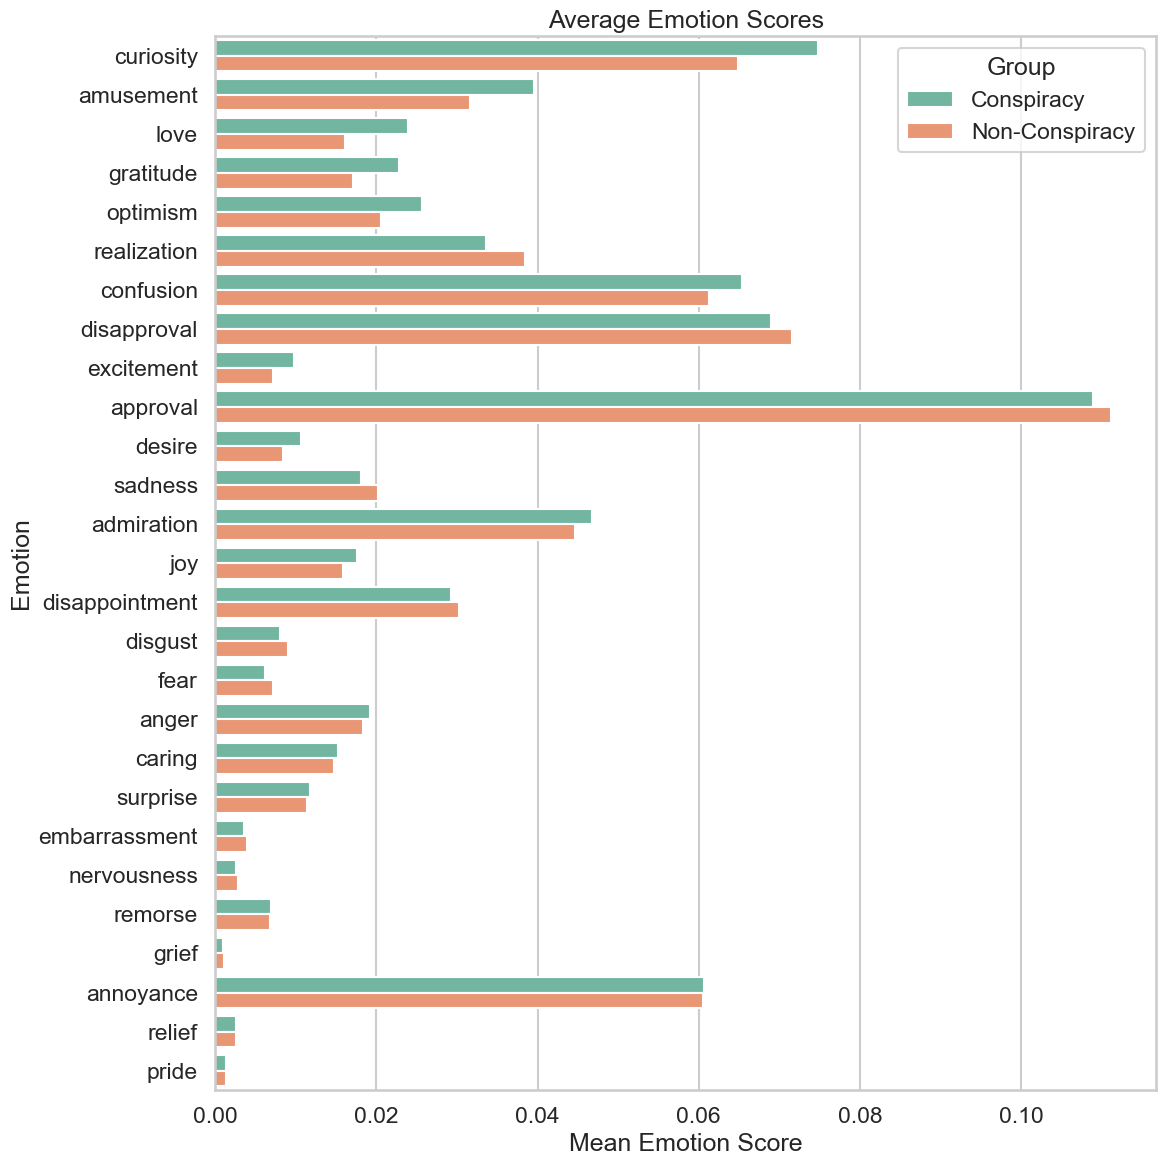

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

# Copia dataframe
df_c = emotions_conspiracy.copy()
df_n = emotions_non_conspiracy.copy()

# Seleziona colonne comuni (escludo id e neutral)
cols_c = {c for c in df_c.columns if c not in ["id", "neutral"]}
cols_n = {c for c in df_n.columns if c not in ["id", "neutral"]}
emotion_cols = sorted(list(cols_c.intersection(cols_n)))

# Conversione a numerico
df_c[emotion_cols] = df_c[emotion_cols].apply(pd.to_numeric, errors="coerce")
df_n[emotion_cols] = df_n[emotion_cols].apply(pd.to_numeric, errors="coerce")

# Calcolo medie
mean_c = df_c[emotion_cols].mean()
mean_n = df_n[emotion_cols].mean()

# DataFrame comparativo
comp = pd.DataFrame({
    "Emotion": emotion_cols,
    "Conspiracy": mean_c.values,
    "Non-Conspiracy": mean_n.values
})

# Ordina per differenza assoluta (più espressivo)
comp["abs_diff"] = (comp["Conspiracy"] - comp["Non-Conspiracy"]).abs()
comp = comp.sort_values("abs_diff", ascending=False)

# Reshape per seaborn
comp_melted = comp.melt(
    id_vars="Emotion",
    value_vars=["Conspiracy", "Non-Conspiracy"],
    var_name="Group",
    value_name="Mean Score"
)

# Plot
plt.figure(figsize=(12, 12))
sns.barplot(
    data=comp_melted,
    y="Emotion",
    x="Mean Score",
    hue="Group",
    palette="Set2"
)

plt.title("Average Emotion Scores")
plt.xlabel("Mean Emotion Score")
plt.ylabel("Emotion")
plt.legend(title="Group")
plt.tight_layout()
plt.savefig("emotion_avg.pdf")
plt.show()


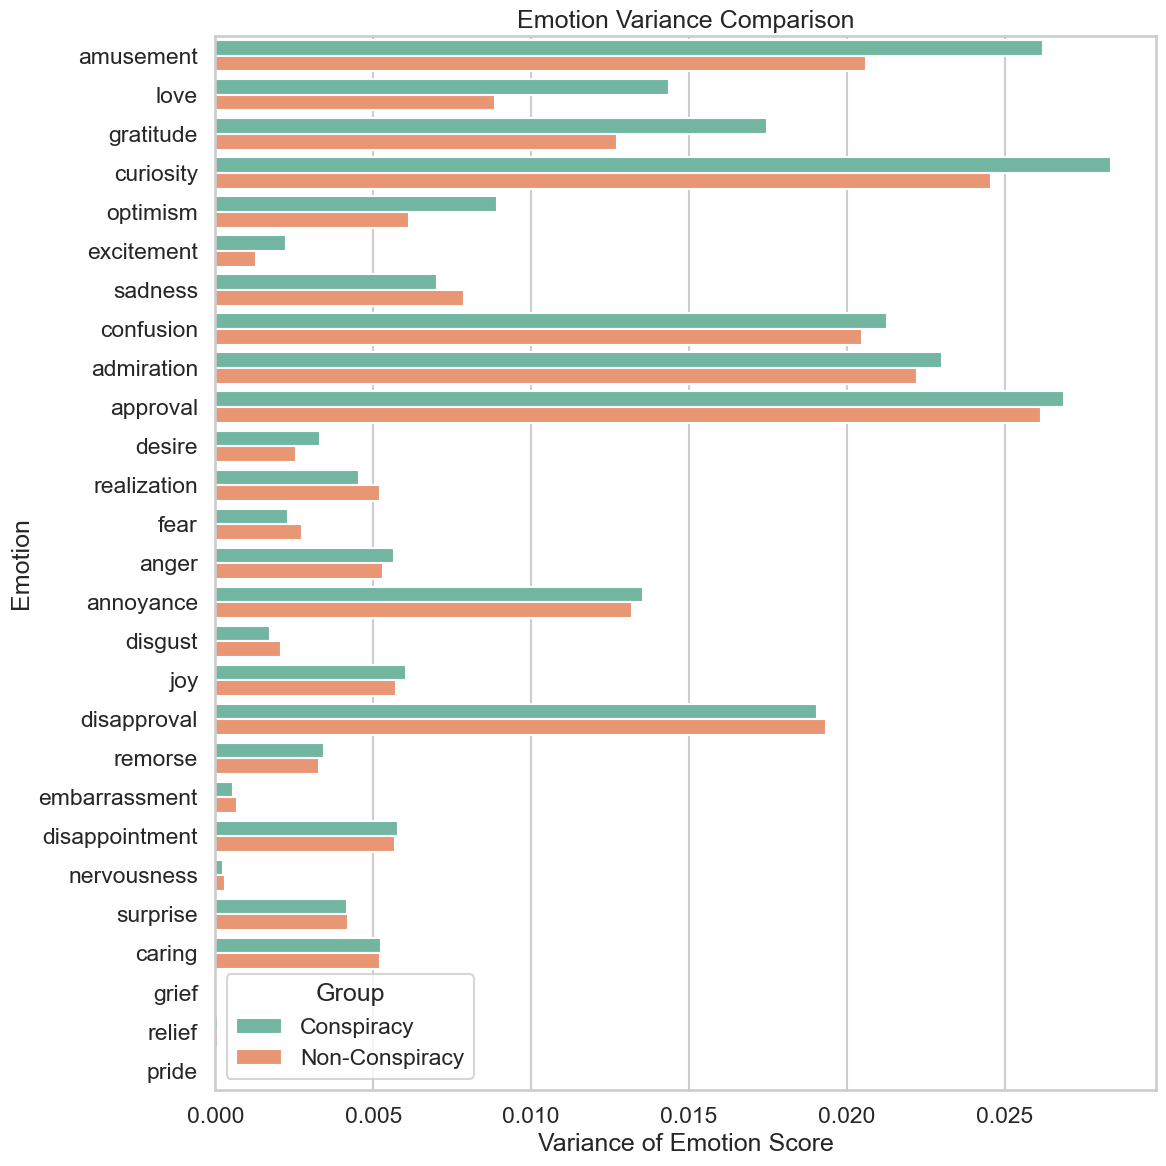

Saved: emotion_variance_comparison_no_neutral.csv


In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

# Copia dataframe
df_c = emotions_conspiracy.copy()
df_n = emotions_non_conspiracy.copy()

# Selezione colonne comuni (escludo id e neutral)
cols_c = {c for c in df_c.columns if c not in ["id", "neutral"]}
cols_n = {c for c in df_n.columns if c not in ["id", "neutral"]}
emotion_cols = sorted(list(cols_c.intersection(cols_n)))

# Conversione a numerico
df_c[emotion_cols] = df_c[emotion_cols].apply(pd.to_numeric, errors="coerce")
df_n[emotion_cols] = df_n[emotion_cols].apply(pd.to_numeric, errors="coerce")

# Calcolo varianze
var_c = df_c[emotion_cols].var()
var_n = df_n[emotion_cols].var()

# DataFrame comparativo
comp = pd.DataFrame({
    "Emotion": emotion_cols,
    "Conspiracy": var_c.values,
    "Non-Conspiracy": var_n.values
})

# Ordina per differenza assoluta di varianza
comp["abs_diff"] = (comp["Conspiracy"] - comp["Non-Conspiracy"]).abs()
comp = comp.sort_values("abs_diff", ascending=False)

# Melt per seaborn
comp_melted = comp.melt(
    id_vars="Emotion",
    value_vars=["Conspiracy", "Non-Conspiracy"],
    var_name="Group",
    value_name="Variance"
)

# Plot
plt.figure(figsize=(12, 12))
sns.barplot(
    data=comp_melted,
    y="Emotion",
    x="Variance",
    hue="Group",
    palette="Set2"
)

plt.title("Emotion Variance Comparison")
plt.xlabel("Variance of Emotion Score")
plt.ylabel("Emotion")
plt.legend(title="Group")
plt.tight_layout()
plt.savefig("emotion_var.pdf")
plt.show()

# Salvataggio opzionale
comp.to_csv("emotion_variance_comparison_no_neutral.csv", index=False)
print("Saved: emotion_variance_comparison_no_neutral.csv")


Selected emotions: 5 / 27


,emotion,mean_conspiracy,mean_non_conspiracy,mean_diff,cohens_d,var_conspiracy,var_non_conspiracy,q_value
18,love,0.023942,0.016160,0.007783,0.072597,0.014360,0.008847,0.0
22,realization,0.033647,0.038414,-0.004767,-0.068145,0.004543,0.005215,0.0
7,curiosity,0.074758,0.064872,0.009886,0.060847,0.028376,0.024568,0.0
20,optimism,0.025648,0.020554,0.005094,0.058937,0.008922,0.006132,0.0
1,amusement,0.039511,0.031672,0.007839,0.051359,0.026222,0.020599,0.0


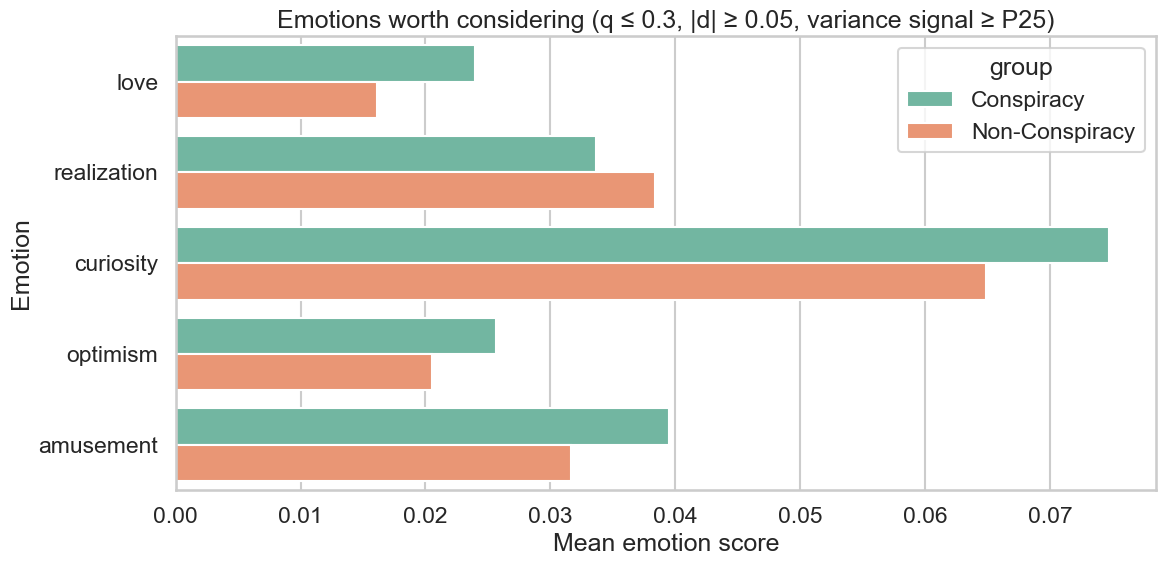

In [129]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sns.set(style="whitegrid", context="talk")

# -----------------------
# Helper: FDR (Benjamini–Hochberg)
# -----------------------
def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    out = np.empty_like(q)
    out[order] = q
    return out

# -----------------------
# 1) Prepare data: common emotion columns, drop id + neutral
# -----------------------
df_c = emotions_conspiracy.copy()
df_n = emotions_non_conspiracy.copy()

cols_c = {c for c in df_c.columns if c not in ["id", "neutral"]}
cols_n = {c for c in df_n.columns if c not in ["id", "neutral"]}
emotion_cols = sorted(list(cols_c.intersection(cols_n)))

df_c[emotion_cols] = df_c[emotion_cols].apply(pd.to_numeric, errors="coerce")
df_n[emotion_cols] = df_n[emotion_cols].apply(pd.to_numeric, errors="coerce")

# -----------------------
# 2) Compute per-emotion statistics
# -----------------------
rows = []
pvals = []

for e in emotion_cols:
    x = df_c[e].dropna().values
    y = df_n[e].dropna().values
    if len(x) < 20 or len(y) < 20:  # safeguard
        continue

    mean_c, mean_n = x.mean(), y.mean()
    var_c, var_n = x.var(ddof=1), y.var(ddof=1)

    # Cohen's d (pooled SD)
    s1, s2 = x.std(ddof=1), y.std(ddof=1)
    sp = np.sqrt(((len(x)-1)*s1**2 + (len(y)-1)*s2**2) / (len(x)+len(y)-2))
    d = (mean_c - mean_n) / sp if sp > 0 else 0.0

    # Mann–Whitney U (non-parametrico, robusto)
    # alternative='two-sided' (default)
    stat, p = mannwhitneyu(x, y, alternative="two-sided")
    pvals.append(p)

    # Variance ratio (log per simmetria)
    vr = (var_c / var_n) if (var_n > 0) else np.inf
    log_vr = np.log(vr) if np.isfinite(vr) and vr > 0 else np.nan

    rows.append({
        "emotion": e,
        "mean_conspiracy": mean_c,
        "mean_non_conspiracy": mean_n,
        "mean_diff": mean_c - mean_n,
        "var_conspiracy": var_c,
        "var_non_conspiracy": var_n,
        "log_var_ratio": log_vr,
        "cohens_d": d,
        "p_value": p
    })

stats = pd.DataFrame(rows)
stats["q_value"] = fdr_bh(stats["p_value"].values)

# -----------------------
# 3) Practical + statistical filtering (tunable thresholds)
# -----------------------
# Practical effect threshold (small but meaningful)
D_MIN = 0.05
Q_MAX = 0.30

# Keep emotions with enough variability (avoid near-constant outputs)
# threshold = 25th percentile of max(var_c, var_n)
var_signal = stats[["var_conspiracy", "var_non_conspiracy"]].max(axis=1)
VAR_MIN = np.quantile(var_signal, 0.25)

selected = stats[
    (stats["q_value"] <= Q_MAX) &
    (stats["cohens_d"].abs() >= D_MIN) &
    (var_signal >= VAR_MIN)
].copy()

selected = selected.sort_values("cohens_d", key=lambda s: s.abs(), ascending=False)

print(f"Selected emotions: {len(selected)} / {len(stats)}")
display(selected[["emotion","mean_conspiracy","mean_non_conspiracy","mean_diff","cohens_d","var_conspiracy","var_non_conspiracy","q_value"]].head(30))

# -----------------------
# 4) Plot only selected emotions (side-by-side bars)
# -----------------------
if len(selected) == 0:
    print("No emotions passed the thresholds. Consider relaxing D_MIN, Q_MAX, or VAR_MIN.")
else:
    plot_df = selected[["emotion","mean_conspiracy","mean_non_conspiracy"]].melt(
        id_vars="emotion",
        var_name="group",
        value_name="mean_score"
    )

    # nicer group names
    plot_df["group"] = plot_df["group"].map({
        "mean_conspiracy": "Conspiracy",
        "mean_non_conspiracy": "Non-Conspiracy"
    })

    # order by absolute Cohen's d
    order = selected["emotion"].tolist()

    plt.figure(figsize=(12, max(6, 0.4*len(order) + 2)))
    sns.barplot(
        data=plot_df,
        y="emotion",
        x="mean_score",
        hue="group",
        order=order,
        palette="Set2"
    )
    plt.title(f"Emotions worth considering (q ≤ {Q_MAX}, |d| ≥ {D_MIN}, variance signal ≥ P25)")
    plt.xlabel("Mean emotion score")
    plt.ylabel("Emotion")
    plt.tight_layout()
    plt.show()


In [134]:
# === Conspiracy vs Non-Conspiracy usando SOLO emozioni (1 cella Jupyter) ===
# Requisiti: pandas, numpy, scikit-learn
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# ----------------------------
# 0) CONFIG: metti qui i path dei 4 CSV
# ----------------------------
# CSV "contenuti" (post/commenti) per i due gruppi noti
PATH_CONSPIRACY_DATA      = "consp2vec_dataset/conspiracy.csv"
PATH_NONCONSPIRACY_DATA   = "consp2vec_dataset/non_conspiracy.csv"

# CSV emozioni (stessa granularità: 1 riga per id) per i due gruppi noti
PATH_CONSPIRACY_EMO       = "consp2vec_dataset/emotions_conspiracy.csv"
PATH_NONCONSPIRACY_EMO    = "consp2vec_dataset/emotions_non_conspiracy.csv"

# Parametri per classificare i "gruppi" (= subreddit_name) in: conspiracy / non / centrale
MIN_ITEMS_PER_GROUP = 50      # minimo numero di post/commenti per subreddit per essere classificato
THRESH_CONSPIRACY   = 0.50    # soglia proba media per dire "conspiracy"
THRESH_NON          = 0.40    # soglia proba media per dire "non_conspiracy"

RANDOM_STATE = 42

# ----------------------------
# 1) LOAD + MERGE su 'id'
# ----------------------------
emo_cols = [
    'neutral', 'confusion', 'curiosity', 'approval', 'love', 'realization',
    'disapproval', 'surprise', 'disappointment', 'annoyance', 'optimism',
    'sadness', 'caring', 'fear', 'anger', 'excitement', 'desire', 'admiration',
    'nervousness', 'joy', 'disgust', 'embarrassment', 'remorse', 'amusement',
    'grief', 'relief', 'gratitude', 'pride'
]

def _read_csv(path):
    df = pd.read_csv(path)
    if 'id' not in df.columns:
        raise ValueError(f"Nel file {path} manca la colonna 'id'.")
    return df

con_data = _read_csv(PATH_CONSPIRACY_DATA)
non_data = _read_csv(PATH_NONCONSPIRACY_DATA)
con_emo  = _read_csv(PATH_CONSPIRACY_EMO)
non_emo  = _read_csv(PATH_NONCONSPIRACY_EMO)

# Keep only needed cols (robusto a extra colonne)
con_emo = con_emo[['id'] + [c for c in emo_cols if c in con_emo.columns]].copy()
non_emo = non_emo[['id'] + [c for c in emo_cols if c in non_emo.columns]].copy()

# Merge
con = con_data.merge(con_emo, on='id', how='inner')
non = non_data.merge(non_emo, on='id', how='inner')

# Label
con['label'] = 1  # conspiracy
non['label'] = 0  # non_conspiracy

df = pd.concat([con, non], ignore_index=True)

# ----------------------------
# 2) Pulizia minima + feature matrix
# ----------------------------
missing_emo = [c for c in emo_cols if c not in df.columns]
if missing_emo:
    raise ValueError(f"Mancano queste colonne emozioni dopo il merge: {missing_emo}")

# Emozioni: assicurati siano numeriche e in [0,1] (se hai logit o altro, togli questo controllo)
for c in emo_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# drop righe senza feature
df = df.dropna(subset=emo_cols + ['subreddit_name', 'label']).copy()

X = df[emo_cols].values
y = df['label'].values

# ----------------------------
# 3) Modello: Logistic Regression (interpretabile) + standardizzazione
# ----------------------------
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="saga", penalty="l2", C=1.0, max_iter=5000, n_jobs=-1, random_state=RANDOM_STATE
    ))
])

# Train/test split per controllo qualità
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)

proba_te = model.predict_proba(X_te)[:, 1]
auc = roc_auc_score(y_te, proba_te)

print(f"Holdout AUC (conspiracy=1): {auc:.4f}\n")
print("Report (soglia 0.5):")
print(classification_report(y_te, (proba_te >= 0.5).astype(int), digits=4))

# CV AUC (opzionale ma utile)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
print(f"\nCV AUC (5-fold): mean={cv_auc.mean():.4f} std={cv_auc.std():.4f}")

# ----------------------------
# 4) Emozioni più "discriminanti"
#    (a) Coefficienti della logreg (standardizzati)  -> importanza direzionale
#    (b) Cohen's d tra classi                        -> effetto descrittivo
# ----------------------------
clf = model.named_steps["clf"]
coefs = clf.coef_.ravel()  # già in spazio standardizzato grazie allo scaler nella pipeline

# Cohen's d
g0 = df[df['label'] == 0][emo_cols]
g1 = df[df['label'] == 1][emo_cols]
m0, m1 = g0.mean(), g1.mean()
s0, s1 = g0.std(ddof=1), g1.std(ddof=1)
# pooled std
sp = np.sqrt(((len(g0)-1)*(s0**2) + (len(g1)-1)*(s1**2)) / (len(g0)+len(g1)-2))
cohen_d = (m1 - m0) / sp.replace(0, np.nan)

disc = pd.DataFrame({
    "emotion": emo_cols,
    "logreg_coef_std": coefs,
    "abs_logreg_coef": np.abs(coefs),
    "mean_conspiracy": m1.values,
    "mean_nonconspiracy": m0.values,
    "cohen_d": cohen_d.values,
    "abs_cohen_d": np.abs(cohen_d.values)
}).sort_values(["abs_logreg_coef", "abs_cohen_d"], ascending=False)

print("\n=== Emozioni più discriminanti (top 15) ===")
display(disc.head(15))

# ----------------------------
# 5) Classificazione dei "gruppi" (subreddit_name) in:
#    - conspiracy
#    - non_conspiracy
#    - centrale
#    Basata sulla PROBABILITÀ media predetta di essere conspiracy
# ----------------------------
# Probabilità conspiracy per ogni item
df["p_conspiracy"] = model.predict_proba(df[emo_cols].values)[:, 1]

grp = (
    df.groupby("subreddit_name")
      .agg(
          n=("id", "count"),
          p_mean=("p_conspiracy", "mean"),
          p_median=("p_conspiracy", "median"),
          p_std=("p_conspiracy", "std")
      )
      .reset_index()
)

# etichetta a 3 stati con vincolo su numerosità
def label_group(row):
    if row["n"] < MIN_ITEMS_PER_GROUP:
        return "insufficient_data"
    if row["p_mean"] >= THRESH_CONSPIRACY:
        return "conspiracy"
    if row["p_mean"] <= THRESH_NON:
        return "non_conspiracy"
    return "centrale"

grp["group_label"] = grp.apply(label_group, axis=1)

# Ordinamenti utili
grp_sorted = grp.sort_values(["group_label", "p_mean"], ascending=[True, False])

print("\n=== Distribuzione etichette gruppi (subreddit) ===")
print(grp["group_label"].value_counts(dropna=False))

print("\n=== Top subreddit più 'conspiracy' (per p_mean) ===")
display(grp[grp["group_label"]=="conspiracy"].sort_values("p_mean", ascending=False).head(15))

print("\n=== Top subreddit più 'non_conspiracy' (per p_mean) ===")
display(grp[grp["group_label"]=="non_conspiracy"].sort_values("p_mean", ascending=True).head(15))

print("\n=== Subreddit in zona centrale (più vicini a 0.5) ===")
central = grp[grp["group_label"]=="centrale"].copy()
central["dist_from_0_5"] = (central["p_mean"] - 0.5).abs()
display(central.sort_values("dist_from_0_5", ascending=True).head(20))

print("\n=== Tabella completa (preview) ===")
display(grp_sorted.head(30))

# Se vuoi esportare i risultati:
# grp.to_csv("subreddit_conspiracy_classification.csv", index=False)
# disc.to_csv("emotion_discriminants.csv", index=False)


/var/folders/24/z4nfgdjs5yg8my2nlvq6mp540000gn/T/ipykernel_14411/967266213.py:42: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Holdout AUC (conspiracy=1): 0.5498

Report (soglia 0.5):
              precision    recall  f1-score   support

           0     0.5382    0.8052    0.6452    729400
           1     0.5414    0.2498    0.3419    671606

    accuracy                         0.5390   1401006
   macro avg     0.5398    0.5275    0.4935   1401006
weighted avg     0.5398    0.5390    0.4998   1401006


CV AUC (5-fold): mean=0.5494 std=0.0005

=== Emozioni più discriminanti (top 15) ===


,emotion,logreg_coef_std,abs_logreg_coef,mean_conspiracy,mean_nonconspiracy,cohen_d,abs_cohen_d
4,love,0.062338,0.062338,0.023813,0.016149,0.071690,0.071690
24,grief,-0.054564,0.054564,0.000996,0.001092,-0.031514,0.031514
15,excitement,0.053068,0.053068,0.009704,0.007228,0.059481,0.059481
5,realization,-0.050957,0.050957,0.033478,0.038088,-0.066163,0.066163
10,optimism,0.049950,0.049950,0.025518,0.020429,0.059098,0.059098
0,neutral,-0.048963,0.048963,0.449529,0.476681,-0.086427,0.086427
2,curiosity,0.044287,0.044287,0.075241,0.065123,0.062009,0.062009
23,amusement,0.042397,0.042397,0.039161,0.031341,0.051495,0.051495
26,gratitude,0.033511,0.033511,0.022901,0.017293,0.045685,0.045685
20,disgust,-0.025189,0.025189,0.008009,0.008947,-0.021570,0.021570



=== Distribuzione etichette gruppi (subreddit) ===
group_label
centrale    33
Name: count, dtype: int64

=== Top subreddit più 'conspiracy' (per p_mean) ===


,subreddit_name,n,p_mean,p_median,p_std,group_label


...

,subreddit_name,n,p_mean,p_median,p_std,group_label



=== Subreddit in zona centrale (più vicini a 0.5) ===


,subreddit_name,n,p_mean,p_median,p_std,group_label,dist_from_0_5
10,TaylorSwift,391458,0.499632,0.479171,0.061358,centrale,0.000368
30,stanford,25473,0.496779,0.480468,0.049939,centrale,0.003221
5,CulinaryPlating,80449,0.490207,0.472746,0.046868,centrale,0.009793
27,shakespeare,66579,0.488014,0.470953,0.048210,centrale,0.011986
9,Patriots,264949,0.485690,0.470168,0.046342,centrale,0.014310
24,keto,139967,0.485184,0.469629,0.046660,centrale,0.014816
17,books,162711,0.484058,0.469232,0.049964,centrale,0.015942
20,communism,50300,0.483034,0.471047,0.039369,centrale,0.016966
32,vegan,191947,0.482914,0.471234,0.042942,centrale,0.017086
6,FlatEarthIsReal,80515,0.482657,0.472267,0.035883,centrale,0.017343



=== Tabella completa (preview) ===


,subreddit_name,n,p_mean,p_median,p_std,group_label
10,TaylorSwift,391458,0.499632,0.479171,0.061358,centrale
30,stanford,25473,0.496779,0.480468,0.049939,centrale
5,CulinaryPlating,80449,0.490207,0.472746,0.046868,centrale
27,shakespeare,66579,0.488014,0.470953,0.048210,centrale
9,Patriots,264949,0.485690,0.470168,0.046342,centrale
24,keto,139967,0.485184,0.469629,0.046660,centrale
17,books,162711,0.484058,0.469232,0.049964,centrale
20,communism,50300,0.483034,0.471047,0.039369,centrale
32,vegan,191947,0.482914,0.471234,0.042942,centrale
6,FlatEarthIsReal,80515,0.482657,0.472267,0.035883,centrale
